# Obtención de Datos y Análisis inicial
Imagina que vas a hacer una ensalada de frutas. El primer paso es ir al mercado (**Extracción**), elegir las frutas (**Definición**) y traerlas a tu mesa de trabajo (**Entorno**).

- Uso de Bibliotecas: **NumPy** es para hacer cuentas rápidas; **Pandas** es como una hoja de Excel súper potente; **Matplotlib** es para hacer los dibujos.
- **Jupyter** es tu cuaderno digital donde escribes código y ves los resultados al instante.
# Tema 1: Obtención de Datos (El Huerto)
La **Obtención de Datos** es el proceso de salir con tu libreta y anotar cuántas manzanas cosechaste, de qué tipo son y cuánto pesan. En Python, no usamos libretas, usamos DataFrames (que son como tablas de Excel inteligentes) de la biblioteca Pandas.


**¿Qué es np.nan?**
En el mundo de los datos (y en la biblioteca NumPy), nan significa "Not a Number" (No es un Número).
En nuestro ejemplo: Es como si en tu libreta de cosecha hubieras dejado un espacio en blanco porque se te olvidó anotar de qué tipo era la manzana.
Para Python: Es una señal de que ahí falta información.

In [83]:
import pandas as pd
import numpy as np

# Creamos los datos de nuestro huerto (Extracción)

datos_huerto = {
    'id_manzana': [1, 2, 3, 4, 5, 6],
    'tipo': ['Gala', 'Gala', 'Manzana Roja', 'Verde', np.nan, 'Gala'], # El nan es una manzana podrida
    'peso_gramos': [150, 155, 170, 120, 145, 150],
    'precio_venta': [10, 11, 15, 9, 10, 10]
}


# Convertimos a DataFrame
df = pd.DataFrame(datos_huerto)
print("Datos recién obtenidos:")
print(df)

Datos recién obtenidos:
   id_manzana          tipo  peso_gramos  precio_venta
0           1          Gala          150            10
1           2          Gala          155            11
2           3  Manzana Roja          170            15
3           4         Verde          120             9
4           5           NaN          145            10
5           6          Gala          150            10


# Tema 2: Limpieza y Transformación (Pre-procesamiento)
Ahora que tienes las frutas, te das cuenta de que algunas están podridas (**datos nulos**) o repetidas. Tienes que lavarlas, quitarles las semillas y cortarlas (**Normalización**).
* Limpieza: Usas **dropna(**) para tirar la fruta podrida o **fillna(**) para rellenar huecos.
* Transformación: Si tienes una etiqueta que dice "Manzana Roja", la conviertes en un número (por ejemplo, 1) para que la computadora la entienda.  

**¿Por usamos nan?**  
En la vida real, los datos nunca son perfectos. Casi siempre te vas a encontrar con archivos donde alguien olvidó llenar una celda o el sensor falló.
 Usamos np.nan para que Python reconozca formalmente que hay un hueco y así poder usar herramientas como fillna() (para rellenar el hueco) o dropna() (para tirar esa fila a la basura).

 **Limpieza y Transformación (Selección y Lavado)**  
No todas las manzanas que recogiste están perfectas. Algunas no tienen etiqueta de "tipo" (faltantes) y otras están repetidas porque las anotaste dos veces (duplicados).
- Limpieza: Es tirar las que no sirven o completar la información.
- Transformación: Es preparar los datos para que sean útiles, como renombrar columnas para que se entiendan mejor.

In [84]:
# 1. Manejo de faltantes: Rellenamos con 'Desconocida'
df['tipo'] = df['tipo'].fillna('Desconocida')

# 2. Eliminación de duplicados:
# Nota: La manzana 1 y 6 son iguales en tipo
df = df.drop_duplicates(subset=['tipo'])

# 3. Renombrado: Cambiamos el nombre de la columna tipa a nombre 'Variedad' 
df = df.rename(columns={'tipo': 'Variedad'})

# 4. Agregar una nueva columna llamada  Calidad:
# Ponemos exactamente 4 valores.
df['calidad'] = [10, 5, 7, 2]

# 5. Ver resultados y estadísticas
print("\nDatos limpios y listos:")
print(df)
print("\nResumen estadístico del peso:")
print(df['peso_gramos'].describe())

# Exportamos para los siguientes temas 
df.to_csv('cosecha_limpia.csv', index=False)


Datos limpios y listos:
   id_manzana      Variedad  peso_gramos  precio_venta  calidad
0           1          Gala          150            10       10
2           3  Manzana Roja          170            15        5
3           4         Verde          120             9        7
4           5   Desconocida          145            10        2

Resumen estadístico del peso:
count      4.000000
mean     146.250000
std       20.564938
min      120.000000
25%      138.750000
50%      147.500000
75%      155.000000
max      170.000000
Name: peso_gramos, dtype: float64


# Tema 1: Estadísticas y Visualización
Imagina que el dueño del huerto te pregunta: "¿Cómo nos fue en general?". En lugar de leerle toda la lista de manzanas, le das un Resumen Descriptivo (el promedio de peso) y le enseñas un Dibujo (gráfica) para que vea qué tipo de manzana vendemos más.

1. Métodos Descriptivos
Usaremos describe() y groupby().

* describe(): Te da un "vistazo rápido" (promedio, máximo, mínimo).
* groupby(): Sirve para agrupar las manzanas por su Variedad y ver, por ejemplo, cuánto pesan las 'Gala' comparadas con las 'Verde'.

2. Visualización con Matplotlib
Vamos a dibujar una gráfica de barras para ver cuánto dinero ganamos por cada variedad.

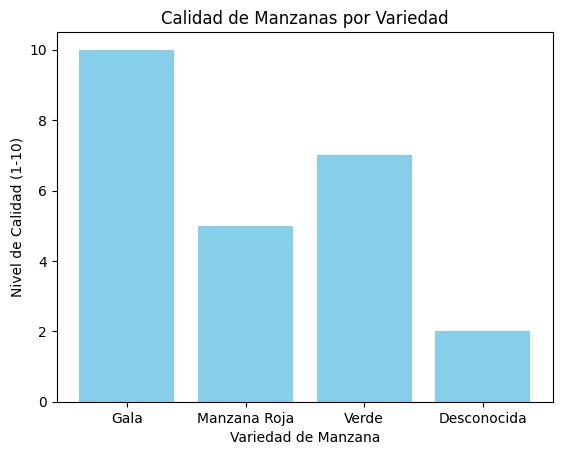

In [85]:
import matplotlib.pyplot as plt

# 1. Creamos la gráfica de barras
# Usamos 'Variedad' para el eje X y 'calidad' para el eje Y
plt.bar(df['Variedad'], df['calidad'], color='skyblue')

# 2. Personalización (Tema 1.1)
plt.xlabel('Variedad de Manzana')       # Etiqueta horizontal
plt.ylabel('Nivel de Calidad (1-10)')  # Etiqueta vertical
plt.title('Calidad de Manzanas por Variedad') # Título del gráfico

# 3. Guardar o mostrar
plt.show()

--- RESUMEN GENERAL DE LA COSECHA ---
       id_manzana  peso_gramos  precio_venta    calidad
count    4.000000     4.000000      4.000000   4.000000
mean     3.250000   146.250000     11.000000   6.000000
std      1.707825    20.564938      2.708013   3.366502
min      1.000000   120.000000      9.000000   2.000000
25%      2.500000   138.750000      9.750000   4.250000
50%      3.500000   147.500000     10.000000   6.000000
75%      4.250000   155.000000     11.250000   7.750000
max      5.000000   170.000000     15.000000  10.000000

El precio promedio por manzana es: $11.00

Peso promedio por variedad:
Variedad
Desconocida     145.0
Gala            150.0
Manzana Roja    170.0
Verde           120.0
Name: peso_gramos, dtype: float64


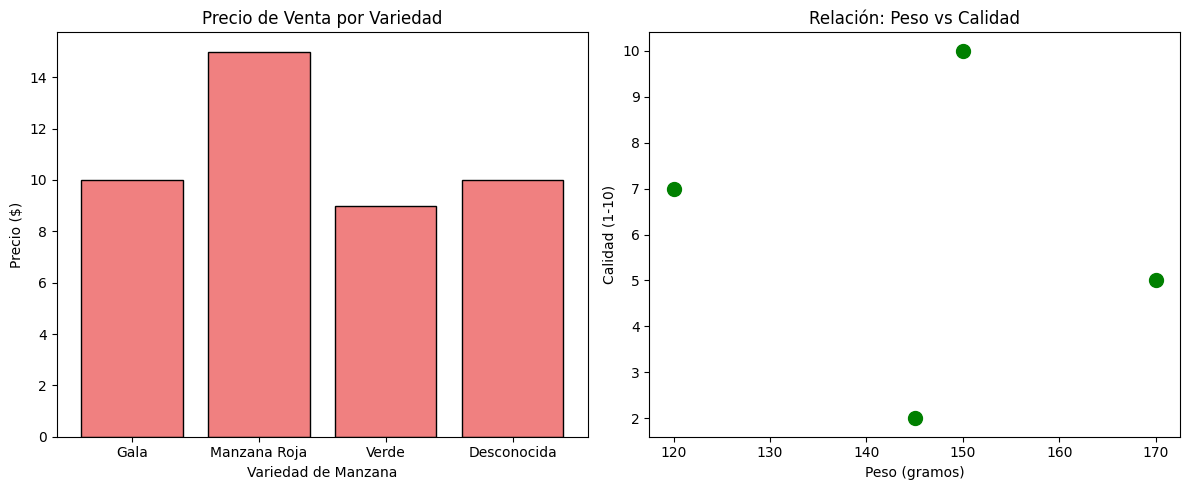

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargamos los datos que limpiamos en el paso anterior
df = pd.read_csv('cosecha_limpia.csv')

# --- ESTADÍSTICA DESCRIPTIVA (Tema 1) ---

# Usamos describe() para ver un resumen completo (mínimos, máximos, promedios) 
print("--- RESUMEN GENERAL DE LA COSECHA ---")
print(df.describe())

# Usamos mean() para el precio promedio 
promedio_precio = df['precio_venta'].mean()
print(f"\nEl precio promedio por manzana es: ${promedio_precio:.2f}")

# Usamos groupby() para ver el peso promedio por cada variedad 
# Esto nos dice qué tipo de manzana suele ser más pesada
peso_por_variedad = df.groupby('Variedad')['peso_gramos'].mean()
print("\nPeso promedio por variedad:")
print(peso_por_variedad)

# --- VISUALIZACIÓN (Tema 1: Barras y Dispersión) ---

# Creamos una figura con dos espacios (uno para barras y otro para puntos)
plt.figure(figsize=(12, 5))

# Gráfico 1: Barras - Precio por Variedad [cite: 19]
plt.subplot(1, 2, 1) # Divide la pantalla en 1 fila y 2 columnas (este es el 1)
plt.bar(df['Variedad'], df['precio_venta'], color='lightcoral', edgecolor='black')
plt.title('Precio de Venta por Variedad') # Personalización: Títulos 
plt.xlabel('Variedad de Manzana')          # Personalización: Etiquetas 
plt.ylabel('Precio ($)')

# Gráfico 2: Dispersión - Peso vs Calidad 
# Sirve para ver si las manzanas más pesadas tienen mejor calidad
plt.subplot(1, 2, 2) # Este es el gráfico 2
plt.scatter(df['peso_gramos'], df['calidad'], color='green', s=100)
plt.title('Relación: Peso vs Calidad')     # 
plt.xlabel('Peso (gramos)')                # 
plt.ylabel('Calidad (1-10)')

# Ajustamos para que no se amontonen los textos
plt.tight_layout()
plt.show()

- describe(): Agregamos esta función porque tu temario la pide específicamente. Es como pedirle a la computadora que te haga un reporte rápido de "salud" de tu huerto sin tener que revisar fila por fila.
- groupby(): Ahora no solo suma, sino que calcula el promedio de peso por variedad. Esto es útil para saber, por ejemplo, si las manzanas Gala son consistentemente más pesadas que las Verde.
- Gráfico de Dispersión (scatter): El temario menciona "dispersión". Este gráfico es genial porque te permite ver si hay una relación entre dos números (en este caso, si el peso influye en la calidad).
- Personalización: Añadimos edgecolor y tight_layout para que los gráficos se vean más profesionales, cumpliendo con la parte de "Personalización de gráficos".